<a href="https://colab.research.google.com/github/dhruvlaungani/ds4420_project/blob/main/ARMA_poc_Dhruv_Lucas_DS4420.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [5]:
#load and prep
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/drive/MyDrive/spotify_merged.csv')
df['stream_window'] = df['stream_window'].apply(ast.literal_eval)

# stationarity test
def adf_test(series):
    result = adfuller(series, autolag='AIC')
    return {'adf_stat': result[0], 'p_value': result[1], 'stationary': result[1] < 0.05}

# best p,q via aic
def select_arma_order(series, max_p=2, max_q=2):
    best_aic = np.inf
    best_order = (1, 0)
    for p in range(1, max_p + 1):
        for q in range(0, max_q + 1):
            try:
                model = ARIMA(series, order=(p, 0, q))
                fit = model.fit()
                if fit.aic < best_aic:
                    best_aic = fit.aic
                    best_order = (p, q)
            except:
                continue
    return best_order, best_aic

def fit_ar_manual(series, p):
    y = np.array(series, dtype=float)
    n = len(y)
    if n <= p:
        return np.zeros(p)
    X = np.column_stack([y[p-i-1:n-i-1] for i in range(p)])
    y_target = y[p:]
    phi = np.linalg.lstsq(X, y_target, rcond=None)[0]
    return phi

# arma fit
def fit_arma_statsmodels(series, p, q):
    model = ARIMA(series, order=(p, 0, q))
    fit = model.fit()
    ar_coefs = fit.arparams if p > 0 else []
    ma_coefs = fit.maparams if q > 0 else []
    resid = fit.resid
    return ar_coefs, ma_coefs, resid, fit.aic

#residual autocorrelation
def ljung_box_test(resid, lags=10):
    max_lags = min(lags, len(resid) - 1)
    if max_lags < 1:
        return np.nan
    result = acorr_ljungbox(resid, lags=max_lags, return_df=True)
    return result['lb_pvalue'].iloc[-1]

#extraction
def extract_features(row):
    series = np.array(row['stream_window'], dtype=float)
    if len(series) < 10:
        return None

    diff = np.diff(series)

    #stationarity
    adf_result = adf_test(diff)
    #best arma order
    (p, q), best_aic = select_arma_order(diff, max_p=2, max_q=2)
    #fit model
    ar_coefs, ma_coefs, resid, aic = fit_arma_statsmodels(diff, p, q)
    #check residuals
    lb_pvalue = ljung_box_test(resid)
    # manual ar for comparison
    ar_manual = fit_ar_manual(diff, p)

    return {
        'title': row['title'],
        'artist': row['artist'],
        'top10': row['top10'],
        'peak_rank': row['peak_rank'],
        #model selection
        'ar_order': p,
        'ma_order': q,
        #coefficients
        'ar1_coef': ar_coefs[0] if len(ar_coefs) > 0 else 0,
        'ar2_coef': ar_coefs[1] if len(ar_coefs) > 1 else 0,
        'ma1_coef': ma_coefs[0] if len(ma_coefs) > 0 else 0,
        'ma2_coef': ma_coefs[1] if len(ma_coefs) > 1 else 0,
        'ar1_manual': ar_manual[0] if len(ar_manual) > 0 else 0,
        #diagnostics
        'model_aic': aic,
        'adf_stat': adf_result['adf_stat'],
        'adf_pvalue': adf_result['p_value'],
        'is_stationary': adf_result['stationary'],
        'ljungbox_pvalue': lb_pvalue,
        'resid_variance': np.var(resid),
        #trajectory features
        'trend_slope': np.polyfit(np.arange(len(series)), series, 1)[0],
        'mean_streams': np.mean(series),
        'std_streams': np.std(series),
        'peak_day': int(np.argmax(series)),
        'volatility': np.std(diff),
        'early_late_ratio': np.mean(series[:7]) / np.mean(series[14:21]) if np.mean(series[14:21]) > 0 else 1,
        #audio features
        'danceability': row['danceability'],
        'energy': row['energy'],
        'valence': row['valence'],
        'tempo': row['tempo'],
        'acousticness': row['acousticness'],
        'loudness': row['loudness'],
        'speechiness': row['speechiness'],
    }

# run extraction
rows = [extract_features(row) for _, row in df.iterrows()]
features_df = pd.DataFrame([r for r in rows if r is not None])

# summary stats
print("feature summary:")
print(features_df[['ar_order', 'ma_order', 'ar1_coef', 'ma1_coef', 'model_aic', 'is_stationary']].describe().round(3))
print(f"\nstationary series: {features_df['is_stationary'].sum()} / {len(features_df)}")
print(f"ljung-box pass (p>0.05): {(features_df['ljungbox_pvalue'] > 0.05).sum()} / {len(features_df)}")

features_df.to_csv('/content/drive/MyDrive/arma_features.csv', index=False)

feature summary:
       ar_order  ma_order  ar1_coef  ma1_coef  model_aic
count  3253.000  3253.000  3253.000  3253.000   3253.000
mean      1.237     0.883    -0.148    -0.530    408.050
std       0.425     0.685     0.487     0.633    113.149
min       1.000     0.000    -2.000    -2.000      8.000
25%       1.000     0.000    -0.474    -0.997    338.230
50%       1.000     1.000    -0.090    -0.867    422.402
75%       1.000     1.000     0.113     0.000    495.235
max       2.000     2.000     2.000     2.000    632.630

stationary series: 1632 / 3253
ljung-box pass (p>0.05): 3218 / 3253


example hit:


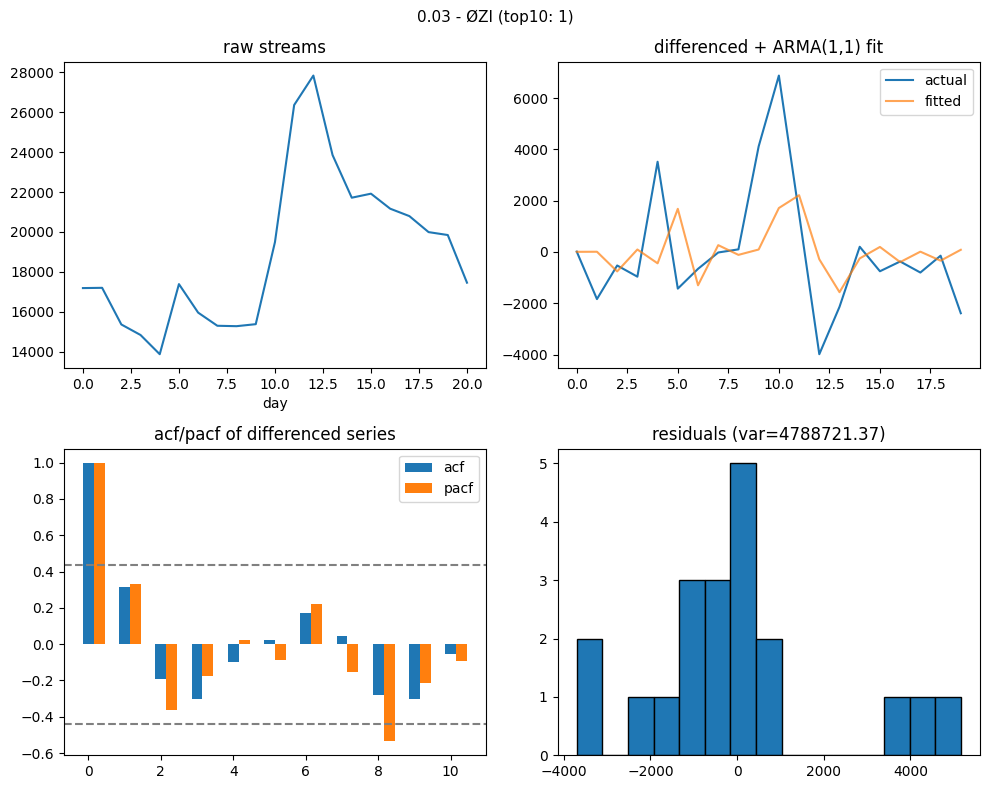


example non-hit:


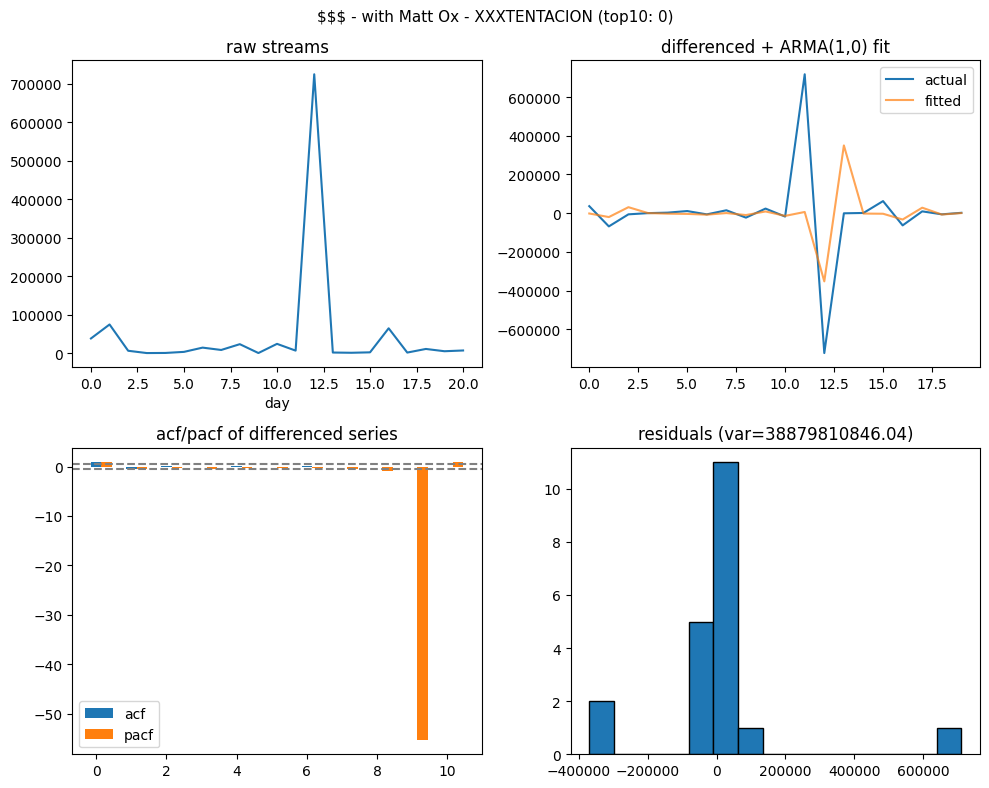

In [6]:
#plots
def plot_song_diagnostics(row, features_row):
    series = np.array(row['stream_window'], dtype=float)
    diff = np.diff(series)

    p, q = int(features_row['ar_order']), int(features_row['ma_order'])
    model = ARIMA(diff, order=(p, 0, q))
    fit = model.fit()
    fitted = fit.fittedvalues
    resid = fit.resid

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    fig.suptitle(f"{row['title']} - {row['artist']} (top10: {row['top10']})", fontsize=11)

    #raw streams
    axes[0, 0].plot(series)
    axes[0, 0].set_title('raw streams')
    axes[0, 0].set_xlabel('day')

    #fitted vs actual
    axes[0, 1].plot(diff, label='actual')
    axes[0, 1].plot(fitted, label='fitted', alpha=0.7)
    axes[0, 1].set_title(f'differenced + ARMA({p},{q}) fit')
    axes[0, 1].legend()

    #acf/pacf
    acf_vals = acf(diff, nlags=10)
    pacf_vals = pacf(diff, nlags=10)
    axes[1, 0].bar(range(len(acf_vals)), acf_vals, width=0.3, label='acf')
    axes[1, 0].bar(np.array(range(len(pacf_vals))) + 0.3, pacf_vals, width=0.3, label='pacf')
    axes[1, 0].axhline(y=1.96/np.sqrt(len(diff)), linestyle='--', color='gray')
    axes[1, 0].axhline(y=-1.96/np.sqrt(len(diff)), linestyle='--', color='gray')
    axes[1, 0].set_title('acf/pacf of differenced series')
    axes[1, 0].legend()

    #residual distribution
    axes[1, 1].hist(resid, bins=15, edgecolor='black')
    axes[1, 1].set_title(f'residuals (var={np.var(resid):.2f})')

    plt.tight_layout()
    plt.show()

# plot one hit and one non-hit
hit_idx = features_df[features_df['top10'] == 1].index[0]
miss_idx = features_df[features_df['top10'] == 0].index[0]

print("example hit:")
plot_song_diagnostics(df.iloc[hit_idx], features_df.iloc[0])

print("\nexample non-hit:")
plot_song_diagnostics(df.iloc[miss_idx], features_df.iloc[1])